# Railway Inventory Planning Platform — Notebook 7 (Rebuilt, STEP30)
**Division MAS · STEP1–28 + Hardening · all figures computed live from current outputs.**

Audience: Stores Officers · Sr.DMM · COS · DRM · PCSTE · Railway Board · Auditors · Engineers · Researchers. Understandable without reading source code.

*TECHNICAL — methodology, analytics internals, hardening.*

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np, pandas as pd
from pathlib import Path
import sys; sys.path.insert(0, str(Path.cwd().parent))
from railway import railway_config as cfg
from railway.governance import division_summary as ds
sns.set_theme(style="whitegrid", palette="deep"); plt.rcParams["figure.dpi"]=110
H = cfg.OUTPUT_DIR / "MAS" / "history"
def rd(n): return pd.read_csv(H/n, dtype={"PL_Code":str}, keep_default_na=False)
def num(s): return pd.to_numeric(s, errors="coerce").fillna(0)
dc=rd("demand_classification.csv"); fc=rd("forecast_results.csv"); lt=rd("lead_time_master.csv")
ssr=rd("safety_stock_results.csv"); rop=rd("rop_results.csv"); srrs=rd("srss_results.csv")
pp=pd.read_csv(H/"procurement_portfolio.csv"); mdh=rd("monthly_demand_history.csv")
score=pd.read_csv(H/"platform_scorecard.csv"); tpj=pd.read_csv(H/"tpj_onboarding_readiness.csv")
for c in ["Current_Stock","ROP","Positive_Gap","SRRS","Average_Rate_Rs","Reorder_Gap_Value_Rs"]:
    if c in srrs: srrs[c]=num(srrs[c])
for c in ["Safety_Stock","Lead_Time_Days","Reorder_Gap","Demand_During_LT","Forecast_Annual"]:
    if c in rop: rop[c]=num(rop[c])
ssr["Safety_Stock"]=num(ssr["Safety_Stock"])
META=ds.metadata(generation_date="2026-06-08"); KPI=ds.compute_kpis()
print("Loaded current outputs:", {"demand":len(dc),"forecast":len(fc),"lead_time":len(lt),
      "safety_stock":len(ssr),"rop":len(rop),"srrs":len(srrs)})

Loaded current outputs: {'demand': 1083, 'forecast': 961, 'lead_time': 702, 'safety_stock': 626, 'rop': 626, 'srrs': 626}


## 2. Platform Architecture
Layered platform: **ingestion** (consolidated I/O) → **governance/config** (division registry) →
**core analytics (STEP1–19)** → **MAS extension (STEP20–28)**, protected by a reproducible
regression + formula test suite (Hardening A/B).

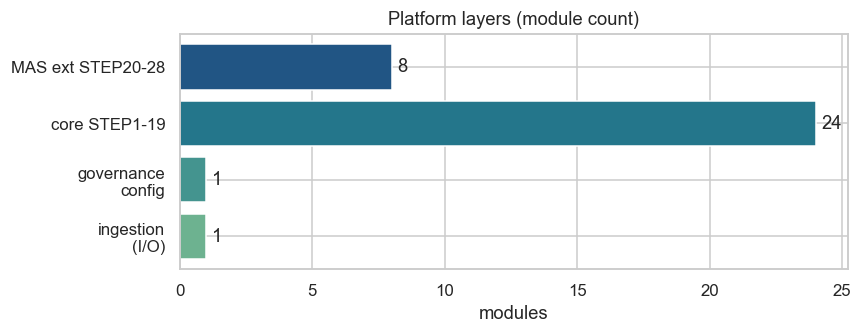

Dependency rule: ingestion -> demand -> forecasting -> inventory -> prioritization -> reporting


In [2]:
layers = {"ingestion\n(I/O)":1,"governance\nconfig":1,"core STEP1-19":24,"MAS ext STEP20-28":8}
fig,ax=plt.subplots(figsize=(8,3.2))
ax.barh(list(layers.keys()), list(layers.values()), color=sns.color_palette("crest",4))
ax.set_title("Platform layers (module count)"); ax.set_xlabel("modules")
for i,v in enumerate(layers.values()): ax.text(v+0.2,i,str(v),va="center")
plt.tight_layout(); plt.show()
print("Dependency rule: ingestion -> demand -> forecasting -> inventory -> prioritization -> reporting")

## 3. Data Foundation
**What data powers the platform?** DMTR issue/procurement registers, SUMMARY OF STOCK HELD
(depot 027534), and the strategic/operational workbooks. Coverage across the planning funnel.

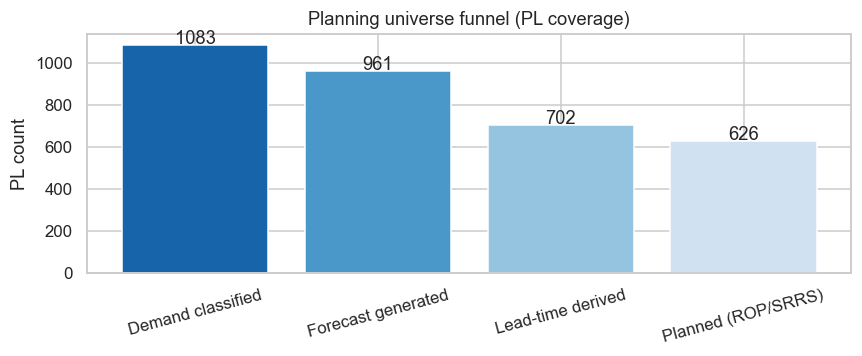

In [3]:
funnel={"Demand classified":len(dc),"Forecast generated":len(fc),"Lead-time derived":len(lt),
        "Planned (ROP/SRRS)":len(rop)}
fig,ax=plt.subplots(figsize=(8,3.4))
ax.bar(funnel.keys(), funnel.values(), color=sns.color_palette("Blues_r",4))
ax.set_title("Planning universe funnel (PL coverage)"); ax.set_ylabel("PL count")
for i,v in enumerate(funnel.values()): ax.text(i,v+8,str(v),ha="center")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## 4. Demand Reconstruction (STEP21A)
**How does MAS consume inventory?** 54 months reconstructed from DMTR issues. Railway spares are
overwhelmingly intermittent.

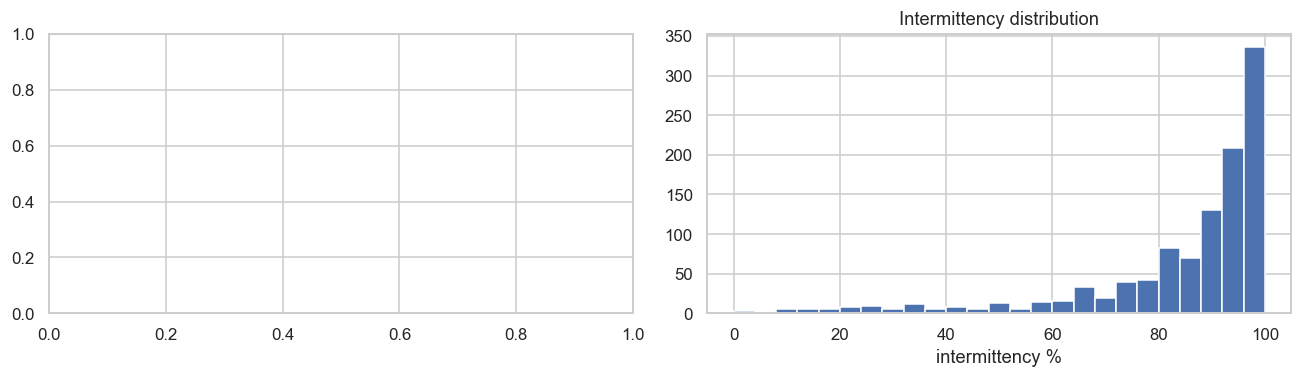

In [4]:
month_cols=[c for c in mdh.columns if c[:1].isdigit() or "20" in c]
fig,axes=plt.subplots(1,2,figsize=(12,3.6))
if month_cols:
    series=num(mdh[month_cols].apply(pd.to_numeric,errors="coerce").sum(axis=0))
    axes[0].plot(range(len(series)), series.values, marker="o", ms=3)
    axes[0].set_title("Aggregate monthly demand (all PLs)"); axes[0].set_xlabel("month index")
inter=num(dc["Intermittency_Pct"]) if "Intermittency_Pct" in dc else num(dc.get("Months_Without_Demand"))
axes[1].hist(inter, bins=25, color="#4c72b0"); axes[1].set_title("Intermittency distribution")
axes[1].set_xlabel("intermittency %")
plt.tight_layout(); plt.show()

## 5. Forecasting (STEP22–23)
**How forecastable is the universe?** Syntetos–Boylan classification (ADI 1.32 / CV² 0.49) routes
each PL to SBA / TSB / Croston / SES-Holt. Coverage **88.7%**.

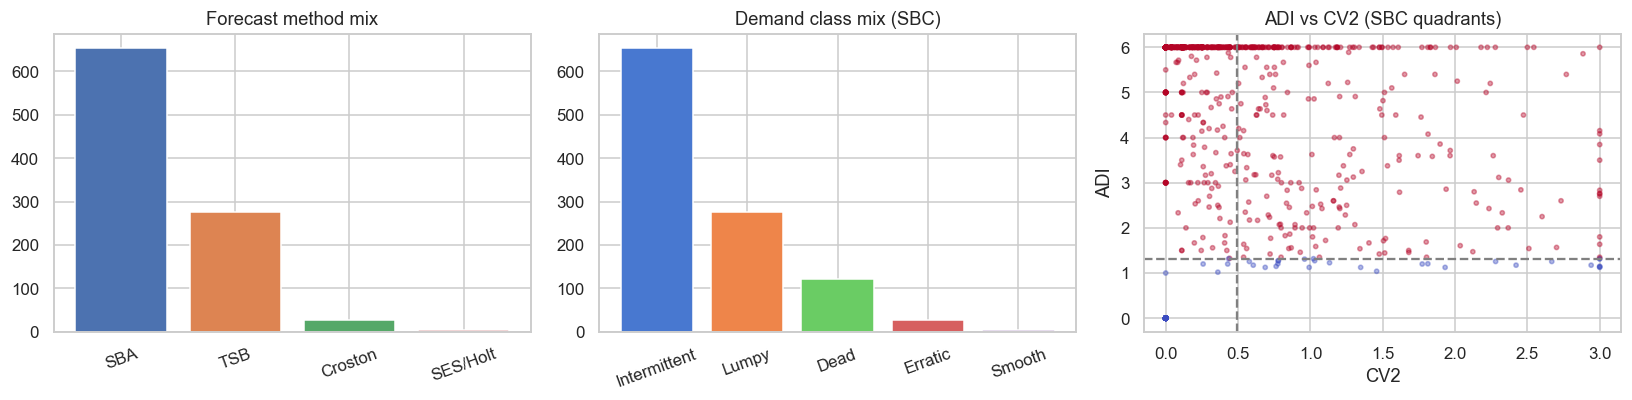

In [5]:
fig,axes=plt.subplots(1,3,figsize=(15,3.8))
mm=fc["Forecast_Method"].value_counts()
axes[0].bar(mm.index, mm.values, color=sns.color_palette("deep",len(mm)))
axes[0].set_title("Forecast method mix"); axes[0].tick_params(axis="x",rotation=20)
cm=dc["Demand_Class"].value_counts()
axes[1].bar(cm.index, cm.values, color=sns.color_palette("muted",len(cm)))
axes[1].set_title("Demand class mix (SBC)"); axes[1].tick_params(axis="x",rotation=20)
adi=num(dc["ADI"]); cv2=num(dc["CV2"])
sc=axes[2].scatter(cv2.clip(0,3), adi.clip(0,6), s=8, alpha=0.4, c=(adi>=1.32).astype(int), cmap="coolwarm")
axes[2].axhline(1.32,ls="--",c="grey"); axes[2].axvline(0.49,ls="--",c="grey")
axes[2].set_title("ADI vs CV2 (SBC quadrants)"); axes[2].set_xlabel("CV2"); axes[2].set_ylabel("ADI")
plt.tight_layout(); plt.show()

## 6. Lead-Time Analytics (STEP23.6B)
**What drives replenishment delay?** Real lead times derived from DMTR procurement chronology
(PO→Receipt, Reqn→Receipt). Coverage **97.8%**.

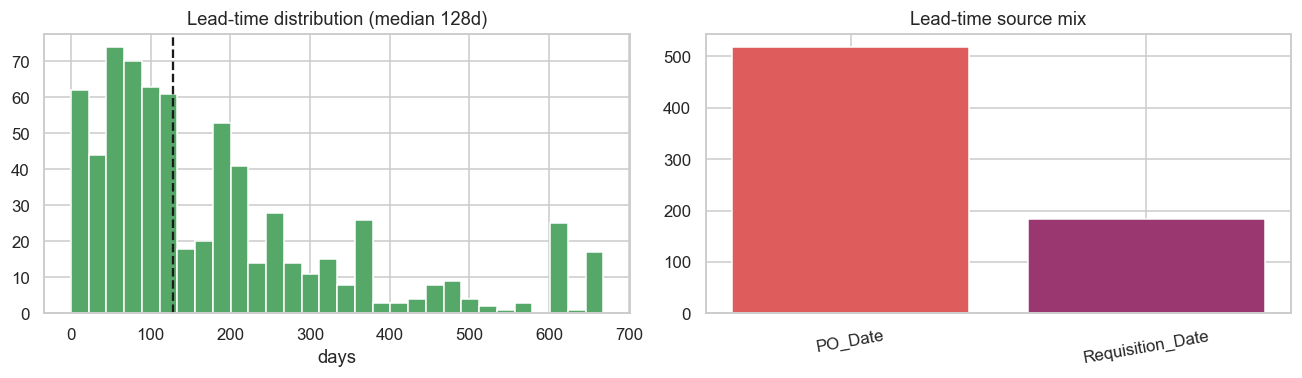

In [6]:
fig,axes=plt.subplots(1,2,figsize=(12,3.6))
ltd=num(lt["Lead_Time_Days"])
axes[0].hist(ltd.clip(0,ltd.quantile(0.98)), bins=30, color="#55a868")
axes[0].axvline(ltd.median(),ls="--",c="k"); axes[0].set_title(f"Lead-time distribution (median {ltd.median():.0f}d)")
axes[0].set_xlabel("days")
sm=lt["Lead_Time_Source"].value_counts()
axes[1].bar(sm.index, sm.values, color=sns.color_palette("flare",len(sm)))
axes[1].set_title("Lead-time source mix"); axes[1].tick_params(axis="x",rotation=10)
plt.tight_layout(); plt.show()

## 7. Criticality Analytics (STEP23.8)
**How much inventory is operationally critical?** Reconstructed from the SUMMARY Type token
(Safety/Vital → Critical; NA → Non-Critical).

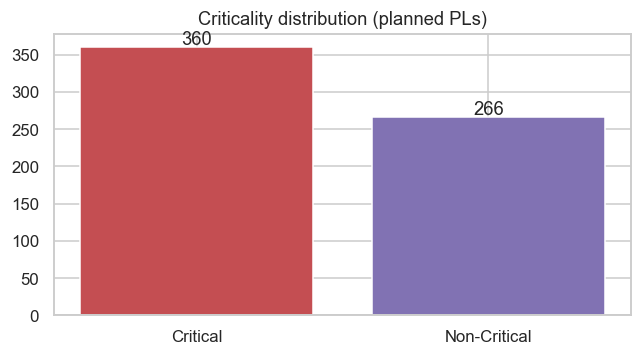

In [7]:
cc=rop["Criticality_Class"].value_counts()
fig,ax=plt.subplots(figsize=(6,3.4))
ax.bar(cc.index, cc.values, color=["#c44e52","#8172b3"])
ax.set_title("Criticality distribution (planned PLs)")
for i,v in enumerate(cc.values): ax.text(i,v+4,str(v),ha="center")
plt.tight_layout(); plt.show()

## 8. Safety Stock (STEP24)
**What drives inventory buffers?** SS = z·σ·√(LT/30.4375); higher service level for Critical items.

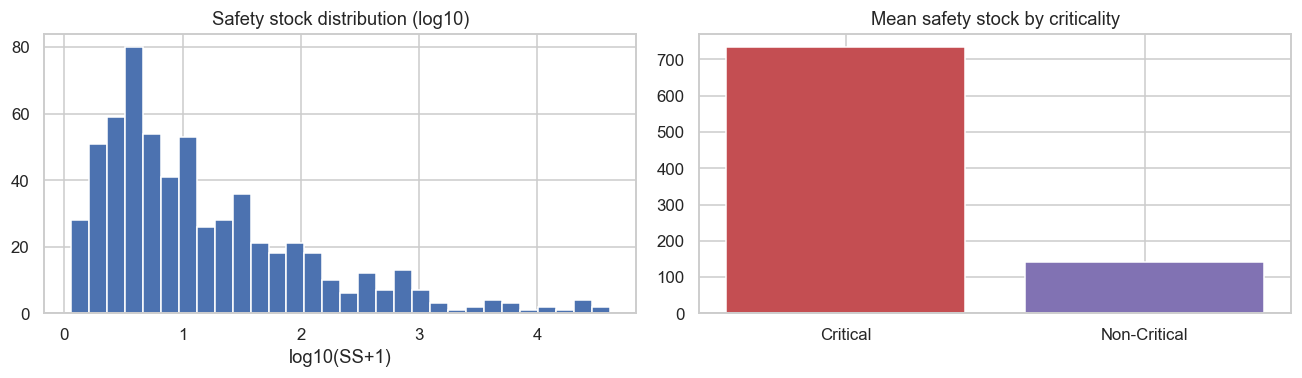

In [8]:
fig,axes=plt.subplots(1,2,figsize=(12,3.6))
sval=ssr["Safety_Stock"]; sval=sval[sval>0]
axes[0].hist(np.log10(sval+1), bins=30, color="#4c72b0")
axes[0].set_title("Safety stock distribution (log10)"); axes[0].set_xlabel("log10(SS+1)")
mss=ssr.groupby("Criticality_Class")["Safety_Stock"].mean()
axes[1].bar(mss.index, mss.values, color=["#c44e52","#8172b3"])
axes[1].set_title("Mean safety stock by criticality")
plt.tight_layout(); plt.show()

## 14. Platform Hardening (Program A/B)
**Can the platform be maintained and extended?** Ingestion extracted (leak removed), config centralized,
regression baseline made reproducible.

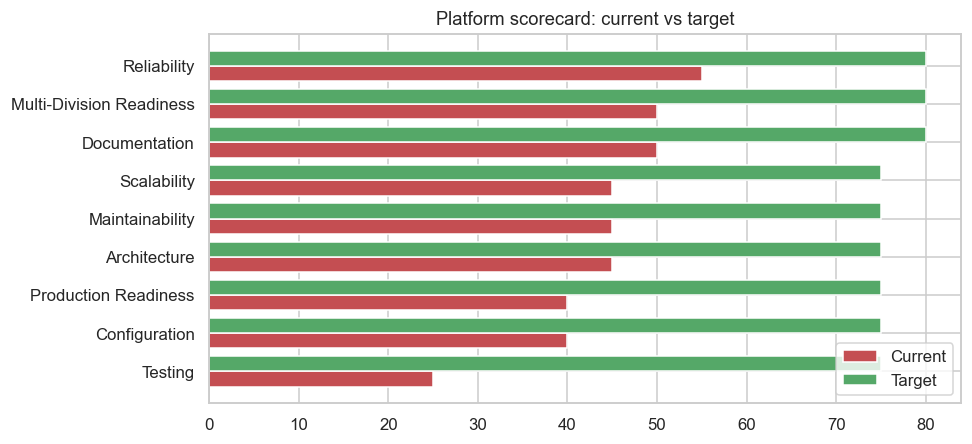

In [9]:
sc=score.sort_values("Current")
fig,ax=plt.subplots(figsize=(9,4.2))
y=np.arange(len(sc))
ax.barh(y-0.2, sc["Current"], height=0.4, label="Current", color="#c44e52")
ax.barh(y+0.2, sc["Target"], height=0.4, label="Target", color="#55a868")
ax.set_yticks(y); ax.set_yticklabels(sc["Dimension"]); ax.legend()
ax.set_title("Platform scorecard: current vs target")
plt.tight_layout(); plt.show()